In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
path = "67-018400.csv"

In [3]:
df = pd.read_csv(path, index_col=None)

In [4]:
df

,timestamp,dtmsid,C_A,C_B,C_C,F,HC_A,HC_B,HC_C,HV_A,...,S_A,S_B,S_C,S_TOT,TEMP_AMB,TEMP_TR,TEMP_OIL,V_A,V_B,V_C
0,2025-10-01T00:00:00,dtmsid1087,34.33,30.60,33.30,0.0,0.0,0.0,0.0,0.0,...,7.83,6.96,7.58,22.37,28.0,0.0,0.0,227.94,227.55,227.58
1,2025-10-01T00:05:00,dtmsid1087,30.77,27.99,30.85,0.0,0.0,0.0,0.0,0.0,...,7.05,6.40,7.05,20.50,28.0,0.0,0.0,228.96,228.55,228.54
2,2025-10-01T00:10:00,dtmsid1087,33.10,32.12,34.96,0.0,0.0,0.0,0.0,0.0,...,7.57,7.33,7.98,22.88,28.0,0.0,0.0,228.63,228.28,228.25
3,2025-10-01T00:15:00,dtmsid1087,29.93,29.71,30.99,0.0,0.0,0.0,0.0,0.0,...,6.85,6.79,7.08,20.72,28.0,0.0,0.0,228.82,228.58,228.55
4,2025-10-01T00:20:00,dtmsid1087,32.57,30.78,33.88,0.0,0.0,0.0,0.0,0.0,...,7.37,6.96,7.66,21.99,27.9,0.0,0.0,226.63,226.43,226.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25521,2025-12-30T23:40:00,dtmsid1087,22.48,25.74,25.26,0.0,0.0,0.0,0.0,0.0,...,5.23,5.95,5.87,17.05,24.0,0.0,0.0,232.52,231.28,232.46
25522,2025-12-30T23:45:00,dtmsid1087,20.27,23.47,23.56,0.0,0.0,0.0,0.0,0.0,...,4.71,5.43,5.47,15.61,24.0,0.0,0.0,232.36,231.31,232.29
25523,2025-12-30T23:50:00,dtmsid1087,20.17,23.38,23.68,0.0,0.0,0.0,0.0,0.0,...,4.69,5.41,5.50,15.60,24.3,0.0,0.0,232.54,231.33,232.35
25524,2025-12-30T23:55:00,dtmsid1087,18.88,21.95,22.67,0.0,0.0,0.0,0.0,0.0,...,4.39,5.08,5.27,14.74,24.6,0.0,0.0,232.35,231.23,232.26


In [7]:
df2 = df.copy()

In [9]:
print(df2['timestamp'].dtype)

object


In [13]:
print(type(df2.iloc[0, 0]))

<class 'str'>


In [14]:
df2['timestamp'] = pd.to_datetime(df2['timestamp'])

In [15]:
print(df2['timestamp'].dtype)

datetime64[ns]


In [19]:

duplicate_rows = df[df["timestamp"].duplicated()]

print(f"จำนวน timestamp ซ้ำ: {len(duplicate_rows)}")


จำนวน timestamp ซ้ำ: 0


In [16]:

full_range = pd.date_range(
    start="2025-10-01 00:00:00",
    end="2025-12-31 23:55:00",
    freq="5min"
)

In [ ]:
print(f"จำนวนช่วงเวลาทั้งหมด: {len(full_range)}")

จำนวนเวลาทั้งหมด: 26496


In [21]:
# หา timestamp ที่หายไป
missing_timestamps = full_range.difference(df2["timestamp"])

print(f"จำนวนช่วงเวลาที่หายไป: {len(missing_timestamps)}")

จำนวนช่วงเวลาที่หายไป: 970


In [22]:
print(missing_timestamps)

DatetimeIndex(['2025-10-02 04:30:00', '2025-10-03 22:55:00',
               '2025-10-04 04:25:00', '2025-10-05 03:50:00',
               '2025-10-06 08:05:00', '2025-10-07 07:40:00',
               '2025-10-08 16:25:00', '2025-10-09 11:35:00',
               '2025-10-11 02:30:00', '2025-10-11 14:50:00',
               ...
               '2025-12-31 23:10:00', '2025-12-31 23:15:00',
               '2025-12-31 23:20:00', '2025-12-31 23:25:00',
               '2025-12-31 23:30:00', '2025-12-31 23:35:00',
               '2025-12-31 23:40:00', '2025-12-31 23:45:00',
               '2025-12-31 23:50:00', '2025-12-31 23:55:00'],
              dtype='datetime64[ns]', length=970, freq=None)


In [23]:
result = df2[df2["timestamp"].between(
    "2025-10-02 03:55:00",
    "2025-10-02 04:45:00"
)]

print(result)


              timestamp      dtmsid    C_A    C_B    C_C    F  HC_A  HC_B  \
335 2025-10-02 03:55:00  dtmsid1087  16.54  17.88  19.56  0.0   0.0   0.0   
336 2025-10-02 04:00:00  dtmsid1087  17.82  16.53  19.66  0.0   0.0   0.0   
337 2025-10-02 04:05:00  dtmsid1087  13.54  13.79  15.82  0.0   0.0   0.0   
338 2025-10-02 04:10:00  dtmsid1087  15.17  14.68  17.28  0.0   0.0   0.0   
339 2025-10-02 04:15:00  dtmsid1087  20.41  20.48  22.91  0.0   0.0   0.0   
340 2025-10-02 04:20:00  dtmsid1087  18.20  18.77  20.95  0.0   0.0   0.0   
341 2025-10-02 04:25:00  dtmsid1087  17.41  16.27  19.31  0.0   0.0   0.0   
342 2025-10-02 04:35:00  dtmsid1087  15.30  14.87  17.75  0.0   0.0   0.0   
343 2025-10-02 04:40:00  dtmsid1087  15.09  14.61  17.46  0.0   0.0   0.0   
344 2025-10-02 04:45:00  dtmsid1087  18.78  19.44  21.66  0.0   0.0   0.0   

     HC_C  HV_A  ...   S_A   S_B   S_C  S_TOT  TEMP_AMB  TEMP_TR  TEMP_OIL  \
335   0.0   0.0  ...  3.76  4.07  4.45  12.28      26.2      0.0       0.0

In [24]:
df_filled = (
    df2.set_index("timestamp")
        .reindex(full_range)
        .rename_axis("timestamp")
        .reset_index()
)

In [25]:
df_filled

,timestamp,dtmsid,C_A,C_B,C_C,F,HC_A,HC_B,HC_C,HV_A,...,S_A,S_B,S_C,S_TOT,TEMP_AMB,TEMP_TR,TEMP_OIL,V_A,V_B,V_C
0,2025-10-01 00:00:00,dtmsid1087,34.33,30.60,33.30,0.0,0.0,0.0,0.0,0.0,...,7.83,6.96,7.58,22.37,28.0,0.0,0.0,227.94,227.55,227.58
1,2025-10-01 00:05:00,dtmsid1087,30.77,27.99,30.85,0.0,0.0,0.0,0.0,0.0,...,7.05,6.40,7.05,20.50,28.0,0.0,0.0,228.96,228.55,228.54
2,2025-10-01 00:10:00,dtmsid1087,33.10,32.12,34.96,0.0,0.0,0.0,0.0,0.0,...,7.57,7.33,7.98,22.88,28.0,0.0,0.0,228.63,228.28,228.25
3,2025-10-01 00:15:00,dtmsid1087,29.93,29.71,30.99,0.0,0.0,0.0,0.0,0.0,...,6.85,6.79,7.08,20.72,28.0,0.0,0.0,228.82,228.58,228.55
4,2025-10-01 00:20:00,dtmsid1087,32.57,30.78,33.88,0.0,0.0,0.0,0.0,0.0,...,7.37,6.96,7.66,21.99,27.9,0.0,0.0,226.63,226.43,226.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26491,2025-12-31 23:35:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26492,2025-12-31 23:40:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26493,2025-12-31 23:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26494,2025-12-31 23:50:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_filled= df_filled.drop(columns=['dtmsid', 'F', 'HC_A', 'HC_B', 'HC_C', 'HV_A', 'HV_B', 'HV_C', 'TEMP_AMB', 'TEMP_TR', 'TEMP_OIL', 'V_A', 'V_B', 'V_C'])

,timestamp,C_A,C_B,C_C,KWH_A,KWH_B,KWH_C,KWH_FWD,KWH_REV,KWH_TOT,...,P_C,P_TOT,Q_A,Q_B,Q_C,Q_TOT,S_A,S_B,S_C,S_TOT
0,2025-10-01 00:00:00,34.33,30.60,33.30,0.0,0.0,0.0,0.0,0.0,195631.0,...,7.50,21.99,1.56,1.39,1.07,4.02,7.83,6.96,7.58,22.37
1,2025-10-01 00:05:00,30.77,27.99,30.85,0.0,0.0,0.0,0.0,0.0,195633.0,...,6.98,20.23,0.99,1.27,0.99,3.25,7.05,6.40,7.05,20.50
2,2025-10-01 00:10:00,33.10,32.12,34.96,0.0,0.0,0.0,0.0,0.0,195635.0,...,7.90,22.65,1.07,1.03,1.13,3.23,7.57,7.33,7.98,22.88
3,2025-10-01 00:15:00,29.93,29.71,30.99,0.0,0.0,0.0,0.0,0.0,195637.0,...,7.01,20.44,0.97,1.35,1.00,3.32,6.85,6.79,7.08,20.72
4,2025-10-01 00:20:00,32.57,30.78,33.88,0.0,0.0,0.0,0.0,0.0,195639.0,...,7.58,21.70,1.04,1.39,1.08,3.51,7.37,6.96,7.66,21.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26491,2025-12-31 23:35:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26492,2025-12-31 23:40:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26493,2025-12-31 23:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26494,2025-12-31 23:50:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
print(df_filled.columns)

Index(['timestamp', 'C_A', 'C_B', 'C_C', 'KWH_A', 'KWH_B', 'KWH_C', 'KWH_FWD',
       'KWH_REV', 'KWH_TOT', 'PF_A', 'PF_B', 'PF_C', 'PF_TOT', 'P_A', 'P_B',
       'P_C', 'P_TOT', 'Q_A', 'Q_B', 'Q_C', 'Q_TOT', 'S_A', 'S_B', 'S_C',
       'S_TOT'],
      dtype='object')


In [28]:
df_filled= df_filled.drop(columns=['PF_A', 'PF_B', 'PF_C'])

In [29]:
mapping = {
    'C_A': 'Ia',
    'C_B': 'Ib',
    'C_C': 'Ic'
}

df_filled = df_filled.rename(columns=mapping)

In [30]:
df_filled

,timestamp,Ia,Ib,Ic,KWH_A,KWH_B,KWH_C,KWH_FWD,KWH_REV,KWH_TOT,...,P_C,P_TOT,Q_A,Q_B,Q_C,Q_TOT,S_A,S_B,S_C,S_TOT
0,2025-10-01 00:00:00,34.33,30.60,33.30,0.0,0.0,0.0,0.0,0.0,195631.0,...,7.50,21.99,1.56,1.39,1.07,4.02,7.83,6.96,7.58,22.37
1,2025-10-01 00:05:00,30.77,27.99,30.85,0.0,0.0,0.0,0.0,0.0,195633.0,...,6.98,20.23,0.99,1.27,0.99,3.25,7.05,6.40,7.05,20.50
2,2025-10-01 00:10:00,33.10,32.12,34.96,0.0,0.0,0.0,0.0,0.0,195635.0,...,7.90,22.65,1.07,1.03,1.13,3.23,7.57,7.33,7.98,22.88
3,2025-10-01 00:15:00,29.93,29.71,30.99,0.0,0.0,0.0,0.0,0.0,195637.0,...,7.01,20.44,0.97,1.35,1.00,3.32,6.85,6.79,7.08,20.72
4,2025-10-01 00:20:00,32.57,30.78,33.88,0.0,0.0,0.0,0.0,0.0,195639.0,...,7.58,21.70,1.04,1.39,1.08,3.51,7.37,6.96,7.66,21.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26491,2025-12-31 23:35:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26492,2025-12-31 23:40:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26493,2025-12-31 23:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26494,2025-12-31 23:50:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
print(df_filled.columns)

Index(['timestamp', 'Ia', 'Ib', 'Ic', 'KWH_A', 'KWH_B', 'KWH_C', 'KWH_FWD',
       'KWH_REV', 'KWH_TOT', 'PF_TOT', 'P_A', 'P_B', 'P_C', 'P_TOT', 'Q_A',
       'Q_B', 'Q_C', 'Q_TOT', 'S_A', 'S_B', 'S_C', 'S_TOT'],
      dtype='object')


In [11]:
df2[['AA', 'AB', 'AC']] = df2[['AA', 'AB', 'AC']].fillna(0)

In [12]:
df2['PEA_No'] = df2['PEA_No'].astype('string')

In [13]:
# print(df2['DATE_Time'].dtype)

df2['DATE_Time'] = pd.to_datetime(df2['DATE_Time'])

In [14]:
df2 = df2.sort_values(
    by=['PEA_No', 'DATE_Time']
).reset_index(drop=True)


In [15]:
df2

,PEA_No,DATE_Time,KWH,kW average,AA,AB,AC,kW exp average,Finergy,Phase
0,6200022544,2025-10-01 00:00:00,0.007,0.028,0.0,0.0,0.0,0.0,false,A
1,6200022544,2025-10-01 00:15:00,0.007,0.028,0.0,0.0,0.0,0.0,false,A
2,6200022544,2025-10-01 00:30:00,0.007,0.028,0.0,0.0,0.0,0.0,false,A
3,6200022544,2025-10-01 00:45:00,0.006,0.024,0.0,0.0,0.0,0.0,false,A
4,6200022544,2025-10-01 01:00:00,0.007,0.028,0.0,0.0,0.0,0.0,false,A
...,...,...,...,...,...,...,...,...,...,...
59515,6200118626,2025-10-31 22:45:00,0.002,0.008,0.0,0.0,0.0,0.0,false,A
59516,6200118626,2025-10-31 23:00:00,0.015,0.060,0.0,0.0,0.0,0.0,false,A
59517,6200118626,2025-10-31 23:15:00,0.014,0.056,0.0,0.0,0.0,0.0,false,A
59518,6200118626,2025-10-31 23:30:00,0.014,0.056,0.0,0.0,0.0,0.0,false,A


In [16]:
# print(df2['ServicePointID'].nunique())
print(df2['PEA_No'].nunique())

20


In [17]:
df2.value_counts(['PEA_No'])

PEA_No    
6200022544    2976
6200030933    2976
6200031047    2976
6200031051    2976
6200031052    2976
6200031073    2976
6200031074    2976
6200031084    2976
6200031085    2976
6200031086    2976
6200031087    2976
6200031088    2976
6200031902    2976
6200032193    2976
6200032194    2976
6200032196    2976
6200032198    2976
6200050504    2976
6200061392    2976
6200118626    2976
Name: count, dtype: int64

In [18]:
s = pd.to_datetime(df2['DATE_Time']).dropna().drop_duplicates().sort_values()

start = s.min().floor('15min')
end   = s.max().ceil('15min') - pd.Timedelta(minutes=15)  

full = pd.date_range(start, end, freq='15min')

In [19]:
day_count = pd.Series(s).groupby(pd.Series(s).dt.date).size()
incomplete_days = day_count[day_count < 96]
print(incomplete_days)

Series([], Name: DATE_Time, dtype: int64)


In [20]:
print(day_count.shape[0])

31


In [21]:
# ถ้า period ตรง 1 เดือนพอดี และคาดหวัง 96 จุด/วัน
expected = 96 * day_count.shape[0]         # คิดจากจำนวนวันจริงที่พบ
actual   = len(s)
print("expected:", expected, "actual:", actual, "missing:", expected - actual)

expected: 2976 actual: 2976 missing: 0


In [22]:
# 1 เดือน = 31 วัน → 2976 จุด
expected_fixed = 96 * 31
print("fixed_expected:", expected_fixed, "missing:", expected_fixed - actual)

fixed_expected: 2976 missing: 0


In [23]:
df2[df2[['PEA_No']].isnull().all(axis=1)]

,PEA_No,DATE_Time,KWH,kW average,AA,AB,AC,kW exp average,Finergy,Phase


In [24]:
df3 = df2.copy()

In [25]:
df3['date'] = df2['DATE_Time'].dt.date

counts_per_day = (
    df3.groupby(['PEA_No', 'date']).size().reset_index(name='count')
)

In [26]:
missing_days = counts_per_day.query("count < 96")
print(missing_days)

Empty DataFrame
Columns: [PEA_No, date, count]
Index: []


In [27]:
pivot = counts_per_day.pivot(index='date', columns='PEA_No', values='count').fillna(0)
pivot

PEA_No,6200022544,6200030933,6200031047,6200031051,6200031052,6200031073,6200031074,6200031084,6200031085,6200031086,6200031087,6200031088,6200031902,6200032193,6200032194,6200032196,6200032198,6200050504,6200061392,6200118626
date,,,,,,,,,,,,,,,,,,,,
2025-10-01,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96
2025-10-02,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96
2025-10-03,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96
2025-10-04,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96
2025-10-05,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96
2025-10-06,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96
2025-10-07,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96
2025-10-08,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96
2025-10-09,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96


In [28]:
df2.isna().sum()

PEA_No            0
DATE_Time         0
KWH               0
kW average        0
AA                0
AB                0
AC                0
kW exp average    0
Finergy           0
Phase             0
dtype: int64

In [29]:
df2.isnull().sum()

PEA_No            0
DATE_Time         0
KWH               0
kW average        0
AA                0
AB                0
AC                0
kW exp average    0
Finergy           0
Phase             0
dtype: int64

In [ ]:
# print(df2.loc[df2['KWH'].isna(), 'DATE_Time'])
# idx = df2[df2['KWH'].isna()].index[0]
# print(idx)

10177   2025-12-15
Name: DATE_Time, dtype: datetime64[ns]
10177


In [ ]:
# df2.loc[idx-5:idx+5]

,PEA_No,DATE_Time,KWH,kW average,AA,AB,AC,kW exp average,Finergy,Phase
10172,6200031051,2025-12-13 23:00:00,0.308000,1.232000,6.0,0.0,0.0,0.0,true,A
10173,6200031051,2025-12-13 23:15:00,0.309000,1.236000,6.0,0.0,0.0,0.0,true,A
10174,6200031051,2025-12-13 23:30:00,0.314000,1.256000,6.0,0.0,0.0,0.0,true,A
10175,6200031051,2025-12-13 23:45:00,0.303000,1.212000,6.0,0.0,0.0,0.0,true,A
10176,6200031051,2025-12-14 00:00:00,0.301000,1.204000,6.0,0.0,0.0,0.0,true,A
10177,6200031051,2025-12-15 00:00:00,NaN,NaN,0.0,0.0,0.0,NaN,true,A
10178,6200031051,2025-12-15 00:15:00,0.089001,0.356003,0.0,0.0,0.0,0.0,true,A
10179,6200031051,2025-12-15 00:30:00,0.066609,0.266435,0.0,0.0,0.0,0.0,true,A
10180,6200031051,2025-12-15 00:45:00,0.078230,0.312920,0.0,0.0,0.0,0.0,true,A
10181,6200031051,2025-12-15 01:00:00,0.051586,0.206346,0.0,0.0,0.0,0.0,true,A


In [ ]:
# df_1085 = df2[
#     (df2['PEA_No'] == '6200031085') &
#     (df2['DATE_Time'] >= '2025-12-14 16:00:00') &
#     (df2['DATE_Time'] <= '2025-12-15 06:00:00')
# ]
# print(df_1085.to_string())

           PEA_No           DATE_Time    KWH  kW average   AA   AB   AC  kW exp average Finergy Phase
22049  6200031085 2025-12-14 16:00:00  0.222       0.888  4.0  0.0  0.0             0.0   false     A
22050  6200031085 2025-12-14 16:15:00  0.219       0.876  4.0  0.0  0.0             0.0   false     A
22051  6200031085 2025-12-14 16:30:00  0.096       0.384  2.0  0.0  0.0             0.0   false     A
22052  6200031085 2025-12-14 16:45:00  0.006       0.024  0.0  0.0  0.0             0.0   false     A
22053  6200031085 2025-12-14 17:00:00  0.057       0.228  1.0  0.0  0.0             0.0   false     A
22054  6200031085 2025-12-14 17:15:00  0.207       0.828  4.0  0.0  0.0             0.0   false     A
22055  6200031085 2025-12-14 17:30:00  0.211       0.844  4.0  0.0  0.0             0.0   false     A
22056  6200031085 2025-12-14 17:45:00  0.211       0.844  4.0  0.0  0.0             0.0   false     A
22057  6200031085 2025-12-14 18:00:00  0.179       0.716  3.0  0.0  0.0           

In [ ]:
#ซ่อมค่า Missing Values

In [ ]:
# df2= df2.drop(index=10177)

In [ ]:
# source_day = df2[
#     (df2['PEA_No'] == '6200031051') &
#     (df2['DATE_Time'] >= '2025-12-21 00:00:00') &
#     (df2['DATE_Time'] <= '2025-12-22 00:00:00')
# ].copy()

# len(source_day)

97

In [ ]:
# source_day['DATE_Time'] = (
#     source_day['DATE_Time']
#     - pd.Timedelta(days=7)
# )
# source_day

,PEA_No,DATE_Time,KWH,kW average,AA,AB,AC,kW exp average,Finergy,Phase
10753,6200031051,2025-12-14 00:00:00,0.124000,0.496000,2.0,0.0,0.0,0.0,true,A
10754,6200031051,2025-12-14 00:15:00,0.107333,0.429333,0.0,0.0,0.0,0.0,true,A
10755,6200031051,2025-12-14 00:30:00,0.114667,0.458667,0.0,0.0,0.0,0.0,true,A
10756,6200031051,2025-12-14 00:45:00,0.092667,0.370667,0.0,0.0,0.0,0.0,true,A
10757,6200031051,2025-12-14 01:00:00,0.089333,0.357333,0.0,0.0,0.0,0.0,true,A
...,...,...,...,...,...,...,...,...,...,...
10845,6200031051,2025-12-14 23:00:00,0.178000,0.712000,3.0,0.0,0.0,0.0,true,A
10846,6200031051,2025-12-14 23:15:00,0.131000,0.524000,3.0,0.0,0.0,0.0,true,A
10847,6200031051,2025-12-14 23:30:00,0.132000,0.528000,3.0,0.0,0.0,0.0,true,A
10848,6200031051,2025-12-14 23:45:00,0.131000,0.524000,3.0,0.0,0.0,0.0,true,A


In [ ]:
# df2 = pd.concat(
#     [df2, source_day],
#     ignore_index=True
# )

In [ ]:
# df2 = (
#     df2
#     .sort_values(['PEA_No', 'DATE_Time'])
#     .reset_index(drop=True)
# )

In [ ]:
#ซ่อม 6200031085

In [ ]:
# source_day = df2[
#     (df2['PEA_No'] == '6200031085') &
#     (df2['DATE_Time'] >= '2025-12-21 18:15:00') &
#     (df2['DATE_Time'] <= '2025-12-22 00:00:00')
# ].copy()

# len(source_day)

24

In [ ]:
# source_day['DATE_Time'] = (
#     source_day['DATE_Time']
#     - pd.Timedelta(days=7)
# )
# source_day

,PEA_No,DATE_Time,KWH,kW average,AA,AB,AC,kW exp average,Finergy,Phase
22802,6200031085,2025-12-14 18:15:00,0.215,0.860,4.0,0.0,0.0,0.0,false,A
22803,6200031085,2025-12-14 18:30:00,0.154,0.616,3.0,0.0,0.0,0.0,false,A
22804,6200031085,2025-12-14 18:45:00,0.225,0.900,4.0,0.0,0.0,0.0,false,A
22805,6200031085,2025-12-14 19:00:00,0.138,0.552,2.0,0.0,0.0,0.0,false,A
22806,6200031085,2025-12-14 19:15:00,0.168,0.672,3.0,0.0,0.0,0.0,false,A
22807,6200031085,2025-12-14 19:30:00,0.041,0.164,1.0,0.0,0.0,0.0,false,A
22808,6200031085,2025-12-14 19:45:00,0.041,0.164,1.0,0.0,0.0,0.0,false,A
22809,6200031085,2025-12-14 20:00:00,0.041,0.164,1.0,0.0,0.0,0.0,false,A
22810,6200031085,2025-12-14 20:15:00,0.041,0.164,1.0,0.0,0.0,0.0,false,A
22811,6200031085,2025-12-14 20:30:00,0.042,0.168,1.0,0.0,0.0,0.0,false,A


In [ ]:
# df2 = pd.concat(
#     [df2, source_day],
#     ignore_index=True
# )

In [ ]:
# df2 = (
#     df2
#     .sort_values(['PEA_No', 'DATE_Time'])
#     .reset_index(drop=True)
# )

In [ ]:
#เช็คซ้ำอีกครั้ง

In [ ]:
# df3 = df2.copy()

In [ ]:
# df3['date'] = df2['DATE_Time'].dt.date

In [ ]:
# counts_per_day = (
#     df3.groupby(['PEA_No', 'date']).size().reset_index(name='count')
# )

In [ ]:
# missing_days = counts_per_day.query("count < 96")
# print(missing_days)

Empty DataFrame
Columns: [PEA_No, date, count]
Index: []


In [30]:
df2.isna().sum()

PEA_No            0
DATE_Time         0
KWH               0
kW average        0
AA                0
AB                0
AC                0
kW exp average    0
Finergy           0
Phase             0
dtype: int64

In [31]:
df2.isnull().sum()

PEA_No            0
DATE_Time         0
KWH               0
kW average        0
AA                0
AB                0
AC                0
kW exp average    0
Finergy           0
Phase             0
dtype: int64

In [32]:
print(df2['AA'].isnull().sum())
print(df2['AB'].isnull().sum())
print(df2['AC'].isnull().sum())

0
0
0


In [33]:
df2 = df2.set_index('DATE_Time')
# df2 = df2.reset_index()

In [34]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 59520 entries, 2025-10-01 00:00:00 to 2025-10-31 23:45:00
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   PEA_No          59520 non-null  string 
 1   KWH             59520 non-null  float64
 2   kW average      59520 non-null  float64
 3   AA              59520 non-null  float64
 4   AB              59520 non-null  float64
 5   AC              59520 non-null  float64
 6   kW exp average  59520 non-null  float64
 7   Finergy         59520 non-null  object 
 8   Phase           59520 non-null  object 
dtypes: float64(6), object(2), string(1)
memory usage: 4.5+ MB


In [35]:
df2.describe()

,KWH,kW average,AA,AB,AC,kW exp average
count,59520.000000,59520.000000,59520.000000,59520.000000,59520.000000,59520.000000
mean,0.145935,0.583741,2.270195,0.000857,0.075437,0.091103
std,0.254523,1.018092,4.828097,0.046547,0.403768,0.339894
min,0.000000,0.000000,-12.000000,0.000000,0.000000,0.000000
25%,0.015000,0.060000,0.000000,0.000000,0.000000,0.000000
50%,0.063000,0.252000,1.000000,0.000000,0.000000,0.000000
75%,0.151000,0.604000,3.000000,0.000000,0.000000,0.000000
max,2.346000,9.384000,42.000000,7.000000,11.000000,2.796000


In [36]:
df_plot = (
    df2.groupby('DATE_Time')['kW average']
       .sum()
       .reset_index()
)

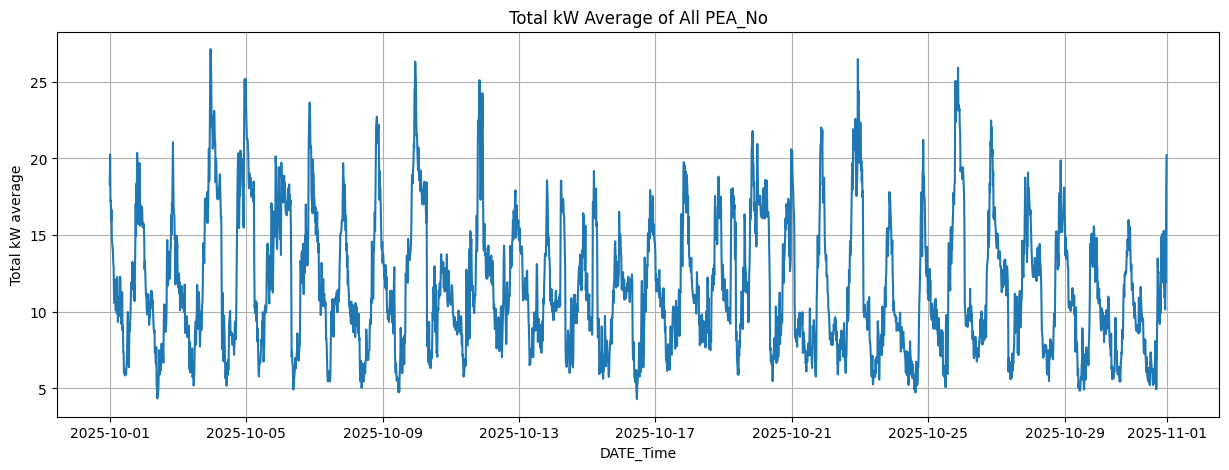

In [37]:
plt.figure(figsize=(15,5))
plt.plot(df_plot['DATE_Time'], df_plot['kW average'])
plt.xlabel('DATE_Time')
plt.ylabel('Total kW average')
plt.title('Total kW Average of All PEA_No')
plt.grid(True)
plt.show()

In [38]:
output_path = "E:/Documents/dtms69/LP_oct2026.parquet"

In [39]:
df2.to_parquet(output_path, engine='pyarrow', index=False)